**makemore: becoming a backprop ninja**

完全使用之前 `4_MLP2_makemore.ipynb` 中的单个隐藏层的多层感知机（关于为什么是"单层", 详见： `4_MLP2_makemore.ipynb`中的 **✅总结** 部分 ）

# 基本代码

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [2]:
# 功能函数 用来比较梯度
# 主要是比较自己手动实现的和pytorch接口的梯度结果是否相同

def cmp(s,dt,t):
    """
    s: 要比较的梯度对象的名称 字符串
    dt: 自己算的dloss/dt的梯度结果
    t: torch张量对象，保存了梯度信息
    """
    ex = torch.all(dt == t.grad).item()  # exact 精确比较
    app = torch.allclose(dt,t.grad)   # approximate 近似比较   函数功能类似于 https://numpy.org/doc/stable/reference/generated/numpy.allclose.html
    maxdiff = (dt - t.grad).abs().max().item()   # 张量中最大梯度值差异
    print(f"{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {str(maxdiff):5s}")

In [3]:
# 初始化
n_embd = 10
n_hidden = 64 

g = torch.Generator().manual_seed(2147483647) 
# 输入层
C  = torch.randn((vocab_size, n_embd), generator=g)

# Layer1 隐藏层
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)*(5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g)*0.1

# Layer2 输出层
W2 = torch.randn((n_hidden, vocab_size), generator=g)*0.1
b2 = torch.randn(vocab_size,  generator=g)*0.1

# BN层
bngain = torch.randn(n_hidden)*0.1 + 1.0
bnbias = torch.randn(n_hidden)*0.1

# 注意，通常会将bias都初始化为0，但这里都初始化为比较小的数字，而不是精确的0
# 这是因为如果初始化为0，可能会掩盖梯度计算实现过程中的错误，所以这里改成比较小的小数，方便纠错自查
# 另外这里加了BN但是还在线性层用了bias，是因为只是想检查梯度的计算结果，并不是和网络训练相关

parameters = [C, W1,b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

4137


In [4]:
batch_size = 32
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

$$ Z = \frac{X - \mu}{\sigma} = \frac{X - \frac{1}{n} \sum_{i=1}^{n} x_i}{\sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}} = \frac{X - \bar{x}}{\sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}}$$


BN论文里的公式：   <https://arxiv.org/pdf/1502.03167>

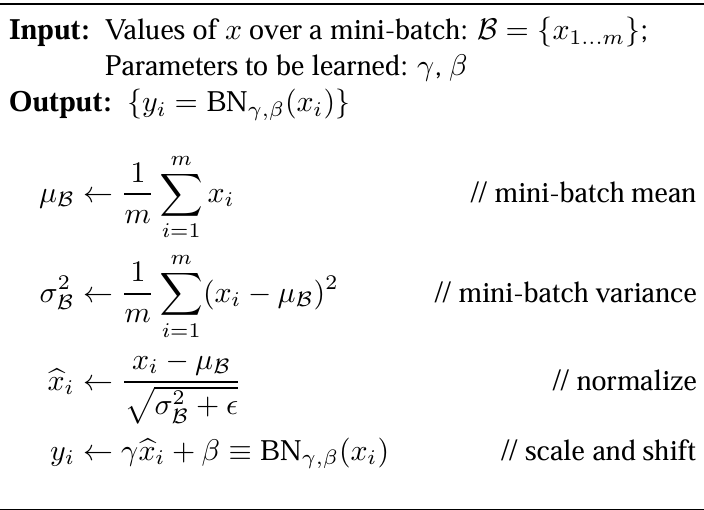

In [5]:
# forward pass
# 这里前向过程拆解的很细(单个op级别)，就是为了后续手动实现反向的时候，好实现
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1) 
# Linear Layer
hprebn = torch.tanh(embcat @ W1 + b1)    # hidden layer pre-activation
# BatchNorm Layer
bnmeani = (1/batch_size)*hprebn.sum(dim = 0, keepdim=True) # bessel correction 贝塞尔纠正 (1/(n-1))
bndiff = hprebn - bnmeani

bndiff2 = bndiff**2
bnvar = (1/batch_size)*bndiff2.sum(dim =0, keepdim = True) # 这里关于均值和方差的计算公式 详见: 4_MLP2_makemore.ipynb 中的  对正态分布进行标准化的公式
bnvar_inv = (bnvar + 1e-5)**(-0.5)  # inverse 上面公式里的分母

bnraw = bndiff*bnvar_inv

hpreact = bngain*bnraw + bnbias

h = torch.tanh(hpreact)  # non-linearity

# Linear Layer 2
logits = h @ W2 + b2 

# cross-entropy loss function(same as F.cross_entropy(logits, Yb))
# loss = F.cross_entropy(logits, Yb)
# 详见： 3_MLP_makemore.ipynb 中的 交叉熵损失函数
logit_maxes = logits.max(dim = 1, keepdim = True).values 
# 这里logits的shape应该是(batch_size,vocab_size), 所以在计算损失的时候，应该是一整行(一个样本的所有27中输出可能值)来处理的，所以要找每行的最大值，也就是在列上进行比较
norm_logits = logits - logit_maxes   # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(dim = 1, keepdim = True)
counts_sum_inv = counts_sum**(-1)  # 倒数, 从除法(除以counts_sum)变成乘法(乘以1/counts_sum)
# if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# 这里如果直接用除法，那么反向的时候会不精确 老师自己实验下来，发现pytorch的除法运算的反向传播实现数组有点奇怪，但是用乘法和负1次幂就没有这个问题
probs = counts*counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(batch_size), Yb].mean()

# 反向传播的时候，会对上面正向传播的变量，比如： logprobs，每个变量前面加个d，dlogprobs, 表示loss对logprobs的梯度值
# backward pass
for p in parameters:
    p.grad = None
# 因为后续要验证自己写的反向过程计算结果和pytorch的是否一样，因此，这里需要保留这些中间计算过程的梯度
# afaik  as far as I know 这里没有更简洁的写法了
for t in [logprobs, probs, counts_sum_inv, counts_sum, counts, norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, bnmeani, hprebn, embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3775, grad_fn=<NegBackward0>)

# 练习

## 练习1-反向传播梯度计算和验证

In [6]:
# dlogprobs计算
# loss = -logprobs[range(batch_size), Yb].mean()
print(logprobs.shape, logprobs[range(batch_size), Yb].shape)
print(logprobs[range(batch_size), Yb])
# 因此，这里 loss的计算本质上等同于:
# loss = -(a + b + c)/3   
# dloss/da = -1/3
# 这里处理的不是3个数，而是32个数了，所以 dlogprobs/dloss = -1/32
# 那么对于[32,27]这个32行，每行27列的矩阵，每行里除了被Yb选中的那个参数梯度是 -1/32， 其余没被选中的梯度应该都是0(梯度为0表示没有影响，为1表示增大~)

torch.Size([32, 27]) torch.Size([32])
tensor([-3.9831, -2.9354, -3.7249, -3.1738, -4.0775, -3.3886, -3.3863, -4.3132,
        -3.2632, -4.2853, -3.0150, -1.4906, -2.9603, -2.6902, -2.8356, -3.3203,
        -3.6728, -3.1880, -3.6408, -3.5031, -2.7445, -2.7670, -4.4127, -4.1274,
        -3.5716, -2.9741, -3.1179, -4.1904, -2.8376, -3.8488, -3.4015, -3.2380],
       grad_fn=<IndexBackward0>)


In [7]:
# dprobs计算
# logprobs = probs.log()
# y = logx  dy/dx = 1/x  dloss/dprobs = dlogprobs * 1/probs
probs.shape

torch.Size([32, 27])

In [14]:
a = torch.tensor(([[1,2,3], [4,5,6]]))
a.shape, a

(torch.Size([2, 3]),
 tensor([[1, 2, 3],
         [4, 5, 6]]))

In [27]:
# dcounts 和 dcounts_sum_inv计算
# probs = counts*counts_sum_inv    # 这个操作本质上有两步，1. replication counts_sum_inv复制成27列 2.对应位置相乘
# dloss/dcounts = dprobs * counts_sum_inv
# dloss/dcounts_sum_inv = dprobs * counts
print(counts.shape, counts_sum_inv.shape, probs.shape)
# 由于执行了广播的原因， 
# 本质上， 32行27列，乘以 32行1列
# 这里 counts的导数其实就是 counts_sum_inv的一列复制成27列即可
# 但是 counts_sum_inv的导数 就相对复杂一些
# counts_sum_inv (32,1)每行唯一的一个元素，其实与counts(32,27)的27个元素进行了乘法运算
# 即：在反向传播过程中，有27个分支节点，因此，其梯度等于这27个分支梯度的和
# 详见： **## 有多分支节点的梯度为什么是求和**部分
dcounts = counts_sum_inv.expand(-1, vocab_size)
dcounts_sum_inv = counts.sum(dim = 1, keepdim = True)
print(dcounts.shape, dcounts_sum_inv.shape)


# counts_sum_inv = counts_sum**(-1)    y = x^a  dy/dx = ax^(a-1)
dcounts_sum = dcounts_sum_inv * (-1)*counts_sum**(-2)
print(dcounts_sum.shape)
# counts_sum = counts.sum(dim = 1, keepdim = True)
# 加法在反向过程中就是直接传递，所以从counts_sum传回给counts，其实就是 1传给27

torch.Size([32, 27]) torch.Size([32, 1]) torch.Size([32, 27])
torch.Size([32, 27]) torch.Size([32, 1])
torch.Size([32, 1])


```python
counts_sum = counts.sum(dim = 1, keepdim = True)
counts_sum_inv = counts_sum**(-1)  
probs = counts*counts_sum_inv
```
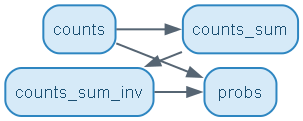

可以看到：这里`counts`有两条路径，一条直接通向`probs`, 另一条通向`counts_sum`

```bash
counts_sum → counts_sum_inv
    ↖             ↓
     counts → probs
```
所以`counts`有两个分支，probs这部分是一个分支的梯度，另一个分支的梯度先求出`counts_sum`的梯度

```python
counts_sum = counts.sum(dim = 1, keepdim = True)
# 加法在反向过程中就是直接传递，所以从counts_sum传回给counts，其实就是 1传给27
```
```bash
     counts            counts_sum
       27                 1
    x x ... x             x
    x x ... x             x
    .                     .
32  .              →  32  .
    .                     .
    x                     x
```

In [28]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one
# 练习1，手动反向传播所有变量，就像上面的正向传递中定义的那样，一个接一个地反向传播

# dlogprobs = torch.zeros((batch_size,vocab_size))
dlogprobs= torch.zeros_like(logprobs)
dlogprobs[range(batch_size), Yb] = -1.0/batch_size

dprobs = dlogprobs*(1.0/probs)   
# 如果预测正确，那么probs里对应元素的值就会接近1，1.0/probs≈1， 则最后求得的梯度肯定是<=dlogprobs的
# 如果预测不正确，那么probs里对应元素的值就会小于1，1.0/probs>1，则最后求得的梯度肯定是>dlogprobs的, 即大于正确结果的梯度，这样更新就会比较快

# dcounts_sum_inv = dprobs * counts.sum(dim = 1, keepdim = True)
# 看 **## 有多分支节点的梯度为什么是求和**部分 
# 反向的时候，是先把各个分支的局部梯度乘以上个节点的全局梯度，再进行相加的
dcounts_sum_inv = (dprobs * counts).sum(dim = 1, keepdim = True)

dcounts_sum = dcounts_sum_inv * (-1)*counts_sum**(-2)

# counts有两个分支
# dcounts = dprobs * counts_sum_inv.expand(-1, vocab_size)  # -1 表示保持该维度大小不变，但是实际上不需要手动扩展，会自动广播的
# torch.expand()（广播视图，不复制数据）, torch.broadcast_to()（与 expand 类似）
# torch.repeat()（实际复制数据，新分配内存）
# https://docs.pytorch.org/docs/2.13/generated/torch.Tensor.repeat.html
# dprobs * counts_sum_inv 是 counts在probs这个分支的梯度
# dcounts_sum.expand(-1, vocab_size)
dcounts = dprobs * counts_sum_inv + dcounts_sum.expand(-1, vocab_size)

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
# cmp('norm_logits', dnorm_logits, norm_logits)
# cmp('logit_maxes', dlogit_maxes, logit_maxes)
# cmp('logits', dlogits, logits)
# cmp('h', dh, h)
# cmp('W2', dW2, W2)
# cmp('b2', db2, b2)
# cmp('hpreact', dhpreact, hpreact)
# cmp('bngain', dbngain, bngain)
# cmp('bnbias', dbnbias, bnbias)
# cmp('bnraw', dbnraw, bnraw)
# cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
# cmp('bnvar', dbnvar, bnvar)
# cmp('bndiff2', dbndiff2, bndiff2)
# cmp('bndiff', dbndiff, bndiff)
# cmp('bnmeani', dbnmeani, bnmeani)
# cmp('hprebn', dhprebn, hprebn)
# cmp('embcat', dembcat, embcat)
# cmp('W1', dW1, W1)
# cmp('b1', db1, b1)
# cmp('emb', demb, emb)
# cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0  
probs           | exact: True  | approximate: True  | maxdiff: 0.0  
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0  
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0  
counts          | exact: True  | approximate: True  | maxdiff: 0.0  


## 练习2-求出交叉熵的解析解直接反向传播(不再逐操作传播)

In [ ]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out
# 反向传播cross_entropy交叉熵的导数,简化公式

# forward pass
# before
# logit_maxes = logits.max(dim = 1, keepdim = True).values 
# norm_logits = logits - logit_maxes
# counts = norm_logits.exp()
# counts_sum = counts.sum(dim = 1, keepdim = True)
# counts_sum_inv = counts_sum**(-1)  
# probs = counts*counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(batch_size), Yb].mean()



## 练习3-求出BN的解析解直接反向传播(不再逐操作传播)

In [ ]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# 求出BN的解析解,直接简化表达式

# forward pass
# before
# bnmeani = (1/n)*hprebn.sum(dim = 0, keepdim=True) 
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = (1/n)*bndiff2.sum(dim =0, keepdim = True) 
# bnvar_inv = (bnvar + 1e-5)**(-0.5)  
# bnraw = bndiff*bnvar_inv
# hpreact = bngain*bnraw + bnbias


## 练习4-综合上面简化后的结果完成整个训练过程

In [ ]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# 其他

## 有多分支节点的梯度为什么是求和

```bash
a b c      x1 o o    * * *
x x x   *  x2 o o  = * * *
x x x      x3 o o    * * *

                                 a11*b1 a12*b2 a13*b3
c = a * b = a[3, 3] * b[3,1] →   a21*b1 a22*b2 a23*b3   = c[3,3]
                                 a31*b1 a32*b2 a33*b3


```
dc/db1?  这里 b1与a11, a12, a13进行了乘法，这个就可以理解为是三个分支

在 `micrograd` 中，如果**在反向传播中，一个节点被多次使用，那么可以认为这个节点的梯度就是多个分支的梯度的和**。 详见： `1_micrograd_from_scratch.ipynb`中`## u9-梯度从赋值变成累加`里的内容

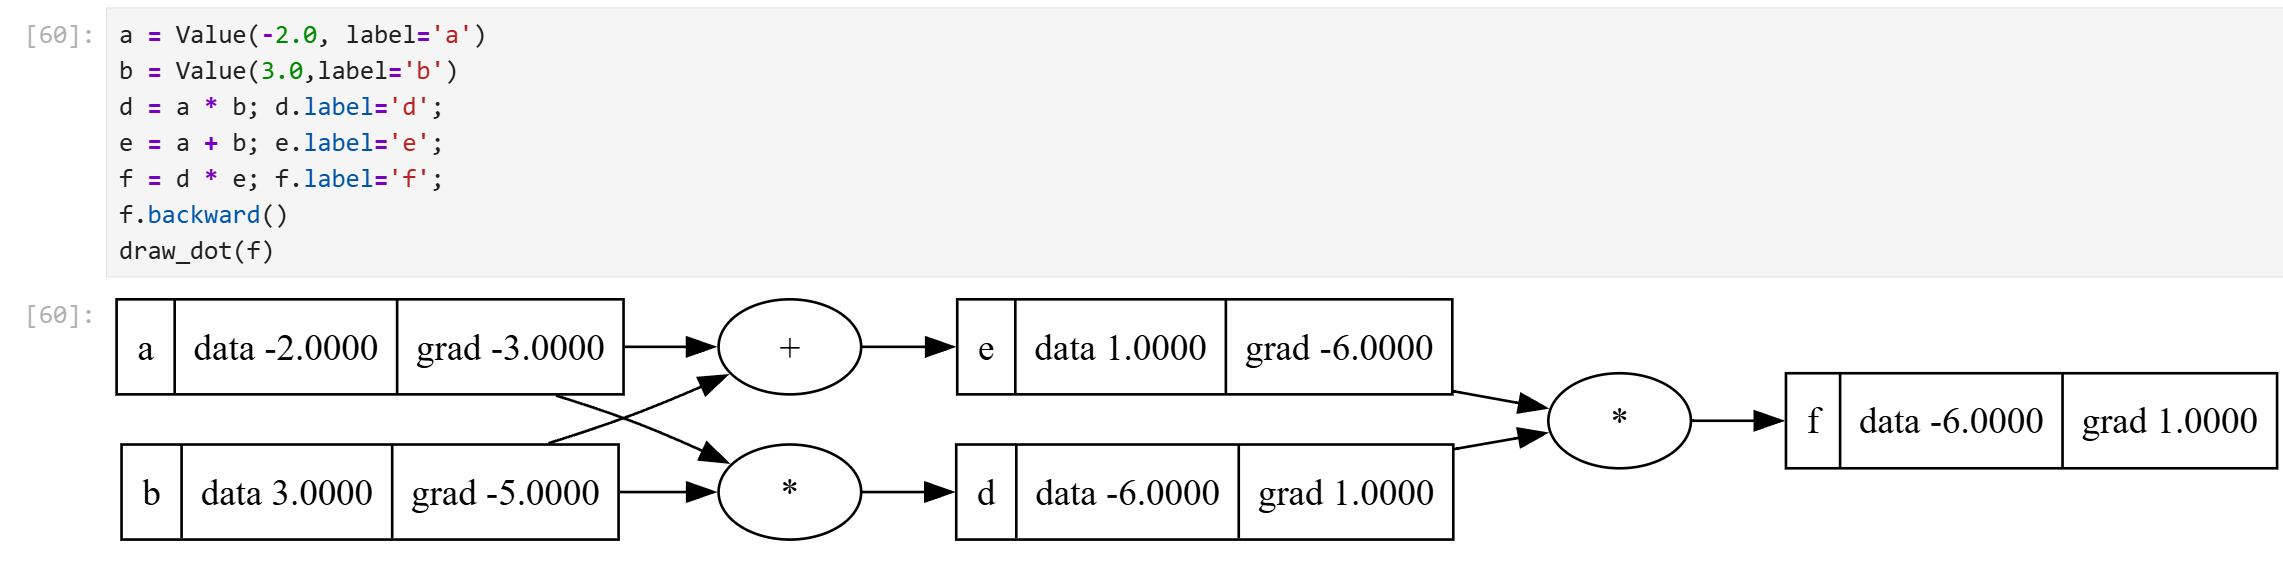

上图的梯度计算：
```bash
以a为例
dd/da = b = 3.0
de/da = 1

a.grad = df/dd * dd/da + df/de *de/da= d.grad* dd/da + e.grad*de/da = 1*3 + (-6)*1 = -3

# 从这里的计算可以看到，反向的时候，是先把各个分支的局部梯度乘以上个节点的全局梯度，再进行相加的
```
因此，对于b1,其梯度也是同行的a11,a12,a13的和

**1. 数学本质：多元函数的链式法则**

在神经网络中，损失函数 $L$ 通常是多个变量的复合函数。假设张量 $x$ 被两个不同的节点引用，分别计算出了 $y_1$ 和 $y_2$，而 $y_1$ 和 $y_2$ 最终又都参与了损失函数 $L$ 的计算。

从数学上看，$L$ 是 $y_1$ 和 $y_2$ 的函数，而 $y_1$ 和 $y_2$ 又是 $x$ 的函数，即：
$$ L = f(y_1, y_2) $$
$$ y_1 = g_1(x), \quad y_2 = g_2(x) $$

根据**多元复合函数的全微分（链式法则）**，损失 $L$ 对 $x$ 的偏导数为：
$$ \frac{\partial L}{\partial x} = \frac{\partial L}{\partial y_1} \frac{\partial y_1}{\partial x} + \frac{\partial L}{\partial y_2} \frac{\partial y_2}{\partial x} $$

- 等式右边的第一项 $\left( \frac{\partial L}{\partial y_1} \frac{\partial y_1}{\partial x} \right)$，就是**通过 $y_1$ 这个分支反向传播回来的梯度**。
- 第二项 $\left( \frac{\partial L}{\partial y_2} \frac{\partial y_2}{\partial x} \right)$，就是**通过 $y_2$ 这个分支反向传播回来的梯度**。

因此，$x$ 的总梯度就是各个分支传递回来的梯度之和。

**2. 直观理解：影响力的叠加（或“责任”的叠加）**

梯度的物理意义是 **“某个变量的微小变化对最终损失函数的影响程度”**。

假设张量 $x$ 的值发生了微小的改变 $\Delta x$：
1. 这个改变会同时传递给 $y_1$ 和 $y_2$。
2. $y_1$ 的改变会导致最终损失变化 $\Delta L_1$。
3. $y_2$ 的改变会导致最终损失变化 $\Delta L_2$。
4. 因为 $y_1$ 和 $y_2$ 是独立计算出来的，它们对 $L$ 的影响是相互独立的，所以 $L$ 的总变化量近似为 $\Delta L \approx \Delta L_1 + \Delta L_2$。

既然 $x$ 通过两条路径影响了 $L$，那么 $x$ 对 $L$ 的**总影响力（总梯度）**，自然等于它在每条路径上产生的影响力的**总和**。

**3. 计算图视角：有向无环图（DAG）中的路径求和**

在深度学习框架中，前向传播被构建为一个有向无环图（计算图）。
- **节点**：张量（变量）。
- **边**：数学运算。

如果节点 $x$ 被多个节点引用，意味着在计算图中，**从 $x$ 到最终的 Loss 节点存在多条不同的路径**。
反向传播的过程，本质上是计算从 Loss 节点到 $x$ 节点的**所有可能路径的梯度乘积之和**。每多一条路径，就会多累加一份梯度。

**4. 工程实现：框架中的“梯度累加”机制**
理解了这个数学原理，就能明白为什么在 PyTorch 等深度学习框架中，张量的 `.grad` 属性默认是**累加（accumulate）** 而不是覆盖的。

当反向传播引擎（Autograd）遍历计算图时，每计算出一条分支的梯度，就会将其**加到**目标张量的 `.grad` 上：
```python
# 伪代码展示反向传播引擎的内部逻辑
for branch in x.outgoing_branches:
    grad_from_branch = compute_gradient(branch)
    x.grad += grad_from_branch  # 注意这里是 +=，而不是 =
```

**总结**

张量被多个节点引用时，梯度求和是因为：**该张量通过多条路径影响了最终的损失，根据多元微积分的链式法则，总梯度等于各条路径上局部梯度的线性叠加。** 这既是严谨的数学推导结果，也符合“总影响力等于各分支影响力之和”的直观逻辑。

## 为什么可以用学习率缩放梯度，但不能用梯度分量来平均梯度（梯度的含义和pytorch抽象对应）

详见： [md/a_难点查漏补缺.md](../md/a_难点查漏补缺.md)

## 数学中，描述函数时提到的“一维、二维、n维”指的是什么

在数学中，描述函数时提到的“一维、二维、n维”**绝大多数情况下指的是“自变量的维度”**（即定义域的维度），但在讨论**函数图像或几何空间**时，指的是“自变量+因变量”的总维度。

为了避免混淆，我们可以根据具体的**语境**来区分：

**1. 指“自变量的维度”（最常见的语境）**
在微积分、最优化理论、机器学习、物理等领域，当我们说一个函数是“n维”时，通常是指它有 **n 个自变量**。
*   **一维函数（一元函数）**：$y = f(x)$。自变量 $x$ 是1维的。
*   **二维函数（二元函数）**：$z = f(x, y)$。自变量 $(x, y)$ 是2维的。
*   **n维函数（n元函数）**：$y = f(x_1, x_2, ..., x_n)$。自变量是n维向量。
*   *注：在传统的中文基础数学教材中，指代自变量个数时更习惯用 **“一元、二元、n元”**，但在现代应用数学和计算机领域，经常直接混用 **“一维、二维、n维”** 来指代输入特征的维度。*

**2. 指“自变量 + 因变量”的维度（几何/图像语境）**

当我们在讨论函数的**图像（Graph）**、**曲面**或它所在的**几何空间**时，“维度”指的是自变量和因变量的总和。
*   **一维函数的图像是二维的**：$y = f(x)$ 的图像是一条线，存在于 **二维空间**（x-y平面）中。
*   **二维函数的图像是三维的**：$z = f(x, y)$ 的图像是一个曲面，存在于 **三维空间**（x-y-z空间）中。
*   **n维函数的图像是 n+1 维的**：$y = f(x_1, ..., x_n)$ 的图像存在于 **n+1 维空间**中。
*   *语境提示：如果句子里带有“空间”、“图像”、“曲面”、“流形”等词，通常是指自变量+因变量的总维度。*

** 3. 如果因变量也是多维的怎么办？**
如果函数的输出（因变量）也有多个（例如 $f: \mathbb{R}^n \to \mathbb{R}^m$），数学上通常**不会**含糊地称其为“n维函数”或“m维函数”，而是使用更严谨的表述：
*   称其为 **“从 n 维到 m 维的映射”**（Mapping from $\mathbb{R}^n$ to $\mathbb{R}^m$）。
*   称其为 **“n维输入，m维输出”** 的向量值函数（Vector-valued function）。
*   此时，定义域是 n 维，值域是 m 维，而函数图像（图）存在于 **n+m 维空间**中。

---

**💡 快速判断指南（总结）**

当你看到“n维”时，可以通过上下文快速判断：

1.  **看搭配词**：
    *   如果是“n维**输入**”、“n维**定义域**”、“n维**特征**”、“n**元**函数” $\Rightarrow$ **指自变量**。
    *   如果是“n维**空间**”、“n维**图像**”、“n维**坐标系**” $\Rightarrow$ **指自变量+因变量**。
2.  **看学科习惯**：
    *   **机器学习/深度学习**：说“输入是1000维的”，绝对是指自变量（特征）有1000个。
    *   **几何/拓扑**：说“这是一个3维流形/3维空间”，通常是指包含因变量在内的整体几何空间。
    *   **偏微分方程**：说“n维热传导方程”，指的是空间自变量有n个（如x, y, z），时间t通常单独算作一维，或者把时间也算作第n+1个自变量。

In [26]:
import graphviz

def plot_compact_forward_flow():
    dot = graphviz.Digraph('CompactForwardFlow', format='png', engine='dot')
    
    # ===== 1. 全局紧凑布局属性 =====
    dot.attr(rankdir='LR', 
             nodesep='0.15', 
             ranksep='0.3', 
             margin='0',
             size='6,3')
    
    # ===== 2. 统一的节点样式 =====
    dot.attr('node', 
             shape='box', 
             style='rounded,filled', 
             fillcolor='#D6EAF8', 
             color='#2E86C1', 
             fontcolor='#1B4F72', 
             fontname='Helvetica', 
             fontsize='13', 
             margin='0.1,0.05', 
             penwidth='1.5')
    
    dot.attr('edge', color='#566573', penwidth='1.5')

    # ===== 3. 定义节点 =====
    dot.node('counts', 'counts')
    dot.node('counts_sum', 'counts_sum')
    dot.node('counts_sum_inv', 'counts_sum_inv')
    dot.node('probs', 'probs')

    # ===== 4. 核心：强制 counts 和 counts_sum_inv 在同一列 =====
    # 使用 subgraph 并设置 rank='same'，强制这两个节点处于同一个垂直列（同一个 rank）
    with dot.subgraph() as same_rank:
        same_rank.attr(rank='same')
        same_rank.node('counts')
        same_rank.node('counts_sum_inv')

    # ===== 5. 定义边（数据流） =====
    # 正常边
    dot.edge('counts', 'counts_sum')
    dot.edge('counts', 'probs')
    dot.edge('counts_sum_inv', 'probs')
    
    # 关键技巧：添加 constraint='false'
    # 这条边依然会绘制箭头，但 Graphviz 在计算节点列位置时会忽略它，
    # 从而允许 counts_sum_inv 被拉回到与 counts 相同的列。
    dot.edge('counts_sum', 'counts_sum_inv', constraint='false')

    # ===== 6. 渲染并保存 =====
    output_filename = 'compact_same_col_flow'
    dot.render(output_filename, view=True, cleanup=True)

if __name__ == '__main__':
    plot_compact_forward_flow()